<a href="https://colab.research.google.com/github/kalvii631/Machine-learning/blob/main/ML_Exp_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
print("24BAD052 B Kalvikannan")

24BAD052 B Kalvikannan


# ML Experiment 10 - Scenario 1: SVD-Based Collaborative Filtering

In [6]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [7]:
# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
ratings = ratings.drop('timestamp', axis=1)

In [8]:
# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
matrix_filled = user_item_matrix.fillna(0)

In [9]:
# 4. NORMALIZATION
user_mean = matrix_filled.mean(axis=1)
matrix_norm = matrix_filled.sub(user_mean, axis=0)

In [10]:
# 5. APPLY SVD
U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

k = 20
U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

In [11]:
# 6. RECONSTRUCTION
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
reconstructed += user_mean.values.reshape(-1, 1)

pred_svd = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

In [12]:
# 7. EVALUATION
actual = user_item_matrix.values[user_item_matrix.notna()]
predicted = pred_svd.values[user_item_matrix.notna()]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("SVD RMSE:", rmse)
print("SVD MAE:", mae)

SVD RMSE: 2.362034411789045
SVD MAE: 1.978958206886534


In [13]:
# 8. RECOMMENDATIONS
def recommend_svd(user_id, n=5):
    user_row = pred_svd.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_svd(1))


Top Recommendations for User 1:
      movieId                              title
507       589  Terminator 2: Judgment Day (1991)
793      1036                    Die Hard (1988)
902      1200                      Aliens (1986)
1445     1968         Breakfast Club, The (1985)
2078     2762            Sixth Sense, The (1999)


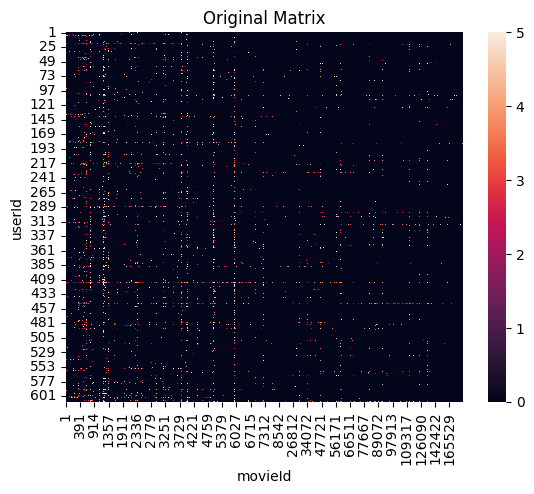

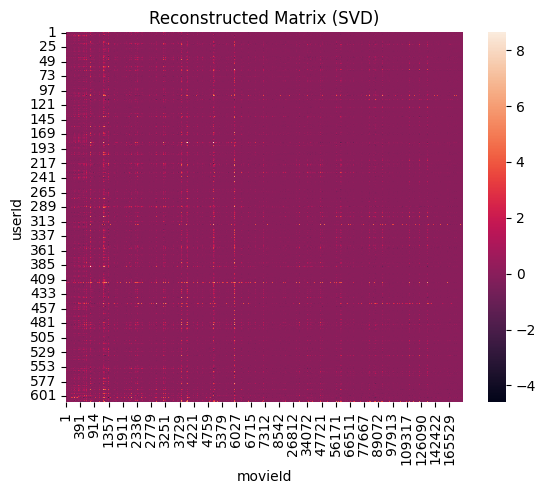

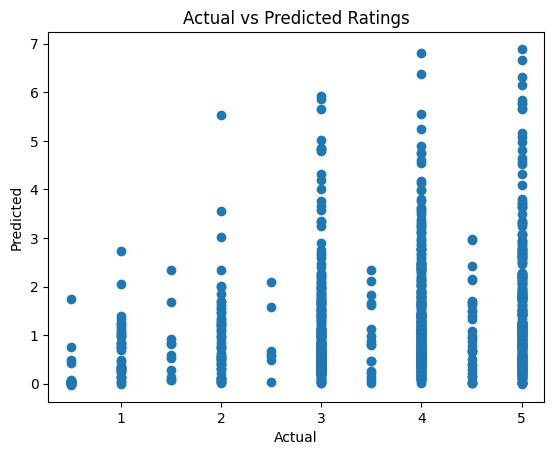

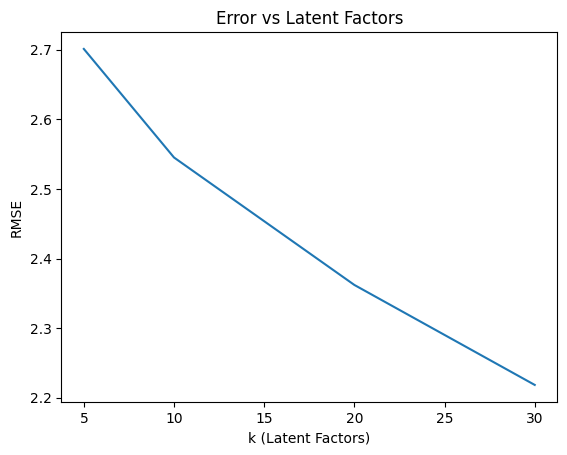

In [14]:
# 9. VISUALIZATION
plt.figure()
sns.heatmap(user_item_matrix.fillna(0))
plt.title("Original Matrix")
plt.show()

plt.figure()
sns.heatmap(pred_svd)
plt.title("Reconstructed Matrix (SVD)")
plt.show()

plt.figure()
plt.scatter(actual[:1000], predicted[:1000])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()

k_values = [5, 10, 20, 30]
errors = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_mean.values.reshape(-1, 1)

    pred = recon[user_item_matrix.notna()]
    err = np.sqrt(mean_squared_error(actual, pred))
    errors.append(err)

plt.figure()
plt.plot(k_values, errors)
plt.xlabel("k (Latent Factors)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

# ML Experiment 10 - Scenario 2: NMF-Based Collaborative Filtering

In [15]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [16]:
# 2. LOAD DATASET (FIXED)
ratings = pd.read_csv('ratings.csv', engine='python', on_bad_lines='skip')
movies = pd.read_csv('movies.csv', engine='python', on_bad_lines='skip')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

In [17]:
# 3. DATA CLEANING
ratings = ratings.dropna()
ratings['userId'] = ratings['userId'].astype(int)
ratings['movieId'] = ratings['movieId'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

In [18]:
# 4. CREATE USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

In [19]:
# 5. HANDLE MISSING VALUES
matrix_filled = user_item_matrix.fillna(0)

In [20]:
# 6. APPLY NMF MODEL
k = 20
model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = model.fit_transform(matrix_filled)
H = model.components_

In [21]:
# 7. RECONSTRUCT MATRIX
reconstructed = np.dot(W, H)
pred_nmf = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

In [22]:
# 8. EVALUATION METRICS
actual = user_item_matrix.values[user_item_matrix.notna()]
predicted = pred_nmf.values[user_item_matrix.notna()]
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("NMF RMSE:", rmse)

def precision_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / len(relevant) if len(relevant) > 0 else 0

print("Precision@5 (User 1):", precision_at_k(1))
print("Recall@5 (User 1):", recall_at_k(1))

NMF RMSE: 2.4588660650487144
Precision@5 (User 1): 0.8
Recall@5 (User 1): 0.02


In [23]:
# 9. TOP-N RECOMMENDATIONS
def recommend_nmf(user_id, n=5):
    user_row = pred_nmf.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_nmf(1))


Top Recommendations for User 1:
      movieId                                   title
507       589       Terminator 2: Judgment Day (1991)
793      1036                         Die Hard (1988)
902      1200                           Aliens (1986)
1057     1374  Star Trek II: The Wrath of Khan (1982)
2078     2762                 Sixth Sense, The (1999)


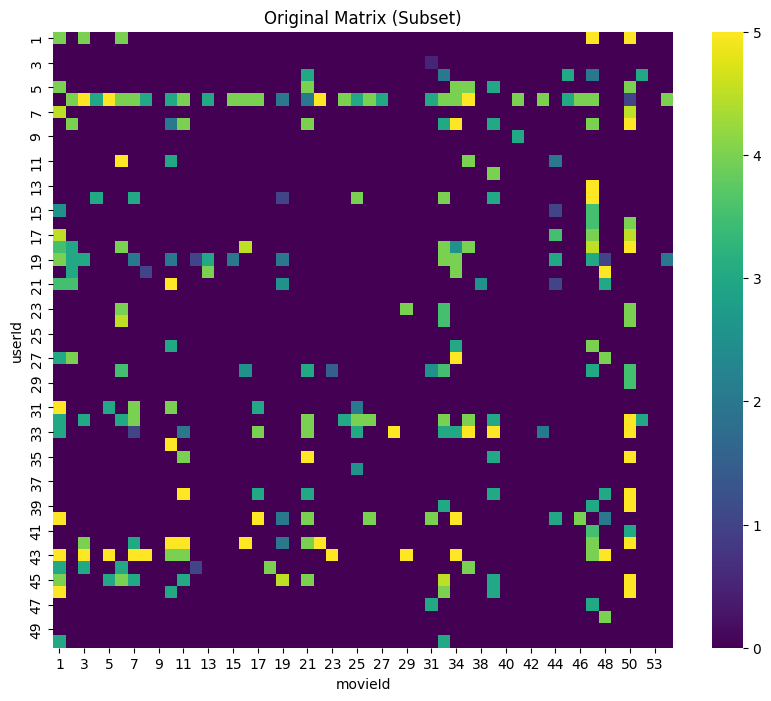

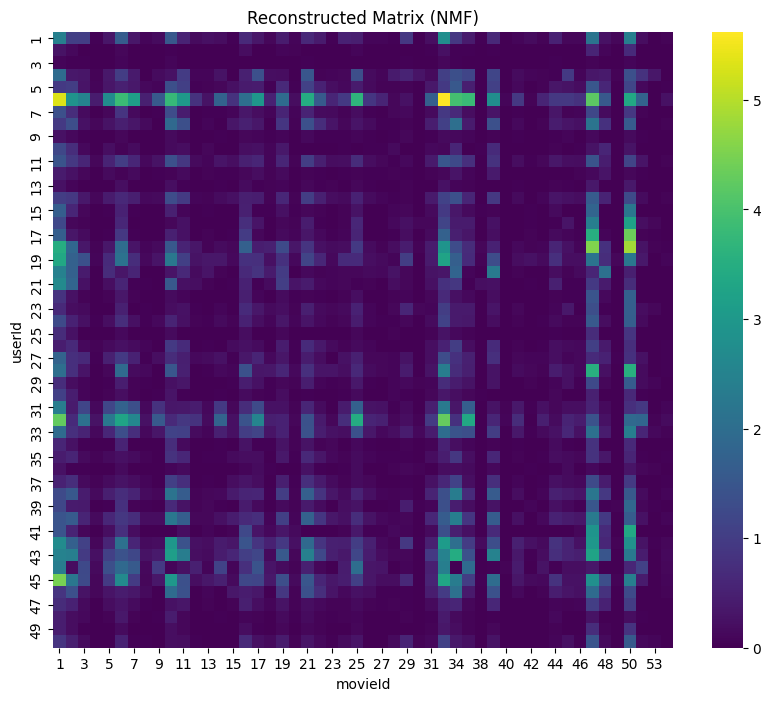

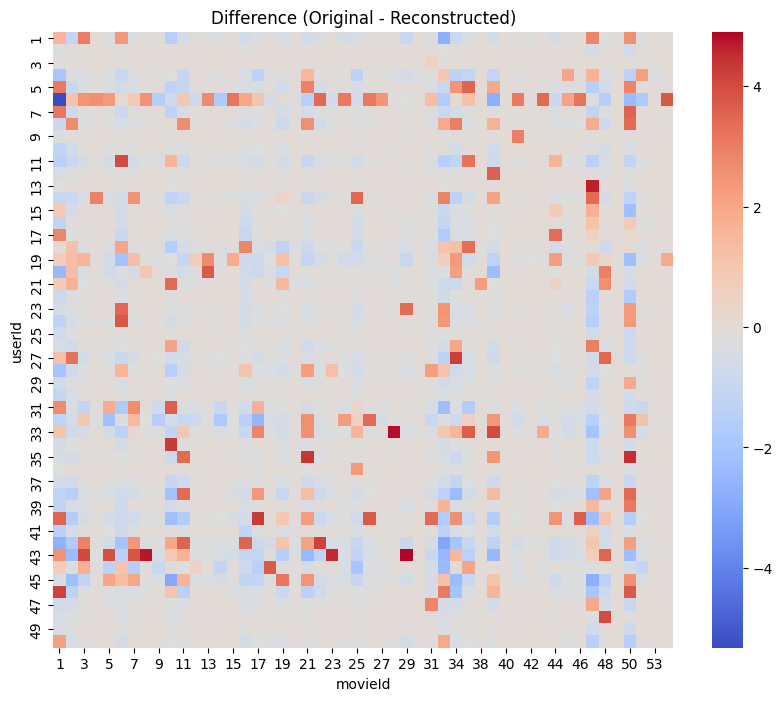

In [24]:
# 10. VISUALIZATION (HEATMAP FIX)
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_nmf.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

difference = subset_original - subset_reconstructed
plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

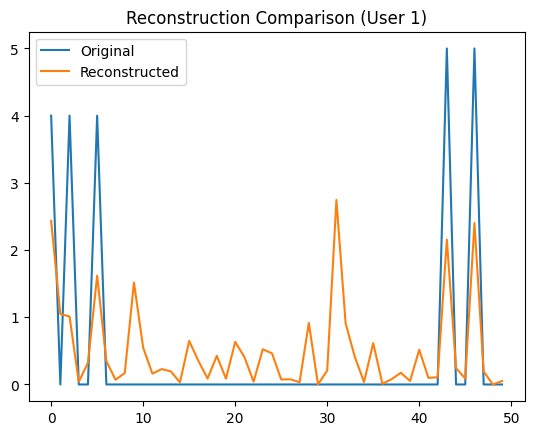

In [25]:
# 11. RECONSTRUCTION COMPARISON
plt.figure()
plt.plot(user_item_matrix.iloc[0].fillna(0).values[:50], label='Original')
plt.plot(pred_nmf.iloc[0].values[:50], label='Reconstructed')
plt.legend()
plt.title("Reconstruction Comparison (User 1)")
plt.show()

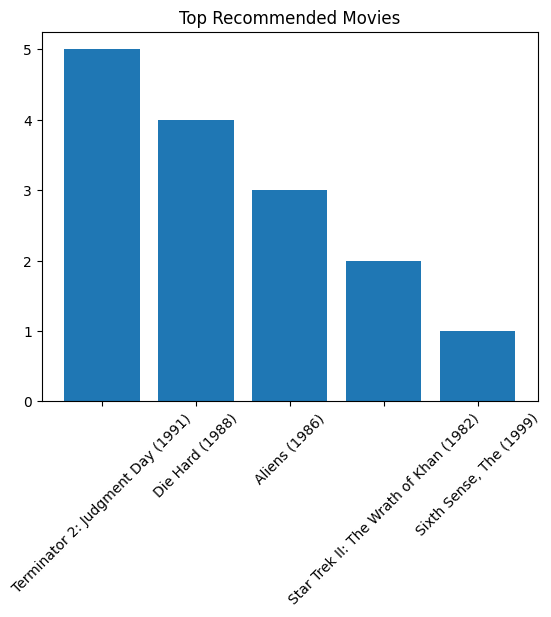

In [26]:
# 12. RECOMMENDATION CHART
top_movies = recommend_nmf(1, 5)

plt.figure()
plt.bar(top_movies['title'], range(5, 0, -1))
plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.show()

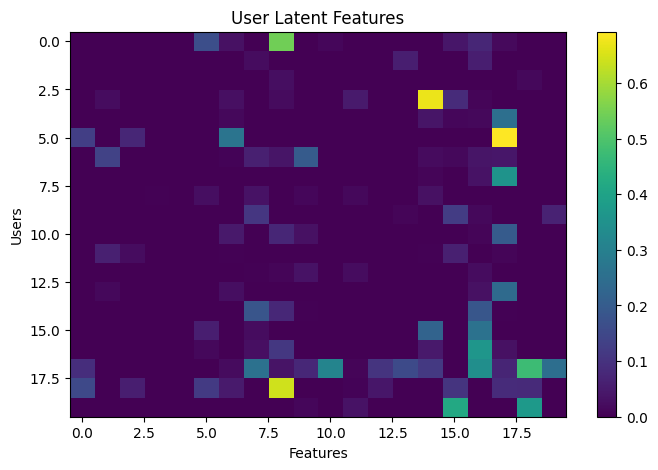

In [27]:
# 13. LATENT FEATURE VISUALIZATION
plt.figure(figsize=(8, 5))
plt.imshow(W[:20, :], aspect='auto')
plt.colorbar()
plt.title("User Latent Features")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


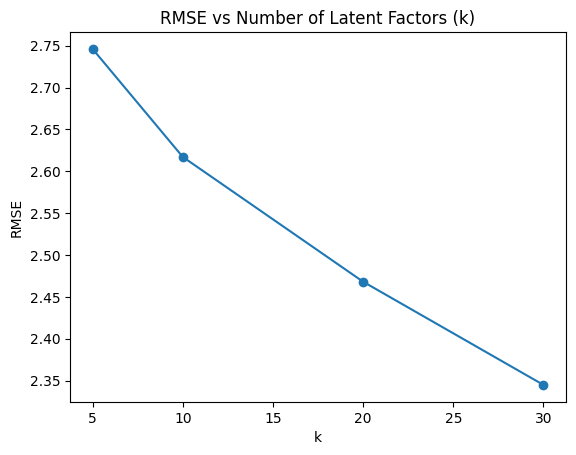

In [28]:
# 14. ANALYSIS: EFFECT OF k
k_values = [5, 10, 20, 30]
rmse_values = []

for k in k_values:
    model = NMF(n_components=k, random_state=42, max_iter=200)
    W_temp = model.fit_transform(matrix_filled)
    H_temp = model.components_
    pred_temp = np.dot(W_temp, H_temp)

    pred_df = pd.DataFrame(pred_temp,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    pred_vals = pred_df.values[user_item_matrix.notna()]
    rmse_k = np.sqrt(mean_squared_error(actual, pred_vals))
    rmse_values.append(rmse_k)

plt.figure()
plt.plot(k_values, rmse_values, marker='o')
plt.title("RMSE vs Number of Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()